In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [35]:
dim = 17
block_size = 4

In [37]:
#Dataset Building
def build_dataset(words):
    blocksize = block_size
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdv, Ydv = build_dataset(words[n1:n2])
Xts, Yts = build_dataset(words[n2:])

torch.Size([182441, 4]) torch.Size([182441])
torch.Size([22902, 4]) torch.Size([22902])
torch.Size([22803, 4]) torch.Size([22803])


In [38]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,dim), generator = g)
W1 = torch.randn((dim*block_size, 300), generator = g)
b1 = torch.randn(W1.shape[1], generator = g)
W2 = torch.randn((300,300), generator = g)
b2 = torch.randn(W2.shape[1], generator = g)
W3 = torch.randn((W2.shape[1],27), generator = g)
b3 = torch.randn(27, generator = g)
parameters = [C, W1, b1, W2, b2, W3, b3]
for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters)

119586

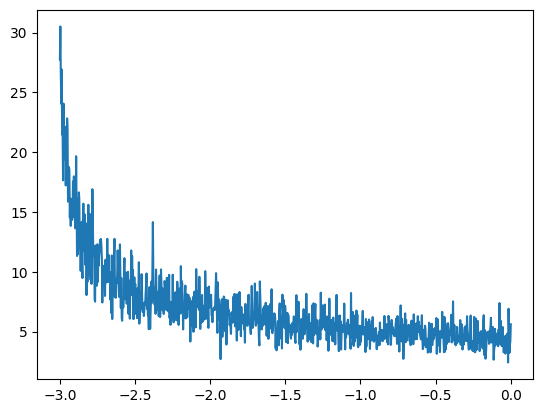

In [25]:
#learning rate tuning
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

lri = []
lossi = []
for i in range(1000):

    ix = torch.randint(0, Xdv.shape[0], (32,))
    
    emb = C[Xdv[ix]]
    h = torch.tanh(emb.view(-1,dim*block_size) @ W1 + b1) # (32,300)
    logits = h @ W2 + b2 # (32,27)
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdims=True)
    # loss = -probs[torch.arange(32), Ydv].log().mean()
    loss = F.cross_entropy(logits,Ydv[ix])
    
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lrs[i]
    for p in parameters:
        p.data += -0.1 * p.grad

    lri.append(lre[i])
    lossi.append(loss.item())

plt.plot(lri,lossi)

In [39]:
minloss = 1000
optimizer = optim.Adam(parameters, lr = 0.01)

In [42]:
#gradient descent

for _ in range(50000):

    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,dim*block_size) @ W1 + b1) # (32,300)
    logits = h @ W2 + b2 # (32,27)
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdims=True)
    # loss = -probs[torch.arange(32), Ytr].log().mean()
    loss = F.cross_entropy(logits,Ytr[ix])
    
    # for p in parameters:
    #     p.grad = None
    # loss.backward()
    
    # for p in parameters:
    #     p.data += -(0.01) * p.grad

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(loss.item())

3.01141095161438


In [43]:
#loss on devset
emb = C[Xdv]
h = torch.tanh(emb.view(-1,dim*block_size) @ W1 + b1) # (32,300)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits,Ydv)
print(loss.item())
if loss.item() < minloss:
    model = [p.detach().clone() for p in parameters]
    minloss = loss.item()

2.805271863937378


In [64]:
minloss

2.1068711280822754

In [65]:
model

[tensor([[ 0.6856, -0.3173,  0.0481, -0.2363,  0.2277,  0.1439, -0.5585,  0.5097,
           0.1725,  0.1678],
         [-0.6628,  0.4433, -0.1656,  0.1617,  1.6107,  3.5123,  1.5400, -1.9520,
           1.7272, -0.5729],
         [ 1.0179,  1.0292, -2.3206,  1.4259,  0.2613,  0.7946,  0.6210,  0.4905,
          -1.1312, -0.1311],
         [-0.8543,  1.9654, -0.9093,  0.8270, -0.4775,  0.4010, -1.1149,  0.7396,
          -0.4350,  0.7116],
         [-0.6504,  0.9030, -0.7189, -0.0387, -1.1003,  1.4893,  1.1242,  1.6787,
          -0.8386, -0.4977],
         [ 0.2962,  1.3509,  0.3131, -1.5181,  0.4127, -0.3344,  1.0601, -0.8620,
          -0.8440, -0.5419],
         [-1.9149,  0.2040, -1.3759, -0.1183,  1.4110, -0.6934,  2.0224,  1.7879,
          -1.4563,  1.4968],
         [ 0.1060,  1.2684, -1.4962,  1.4849,  0.2796,  2.1249, -0.1446,  0.1125,
          -0.6633, -1.0308],
         [-0.8114, -0.3263, -0.5251, -0.5435, -0.1161, -0.2501,  0.6468, -0.3325,
           0.1180,  0.2142],
 

In [33]:
#loss on testset
emb = C[Xts]
h = torch.tanh(emb.view(-1,dim*block_size) @ W1 + b1) # (32,300)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits,Yts)
print(loss.item())

2.3147897720336914


In [34]:
#sampling from our model

g = torch.Generator().manual_seed(2147483647)

for _ in range(20): 
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

creylan.
aelynn.
brelynnlehne.
ariyuna.
cosbian.
aasamarenn.
keelenirelys.
alannei.
rea.
dayl.
alany.
aurlyenejaylonno.
kalenn.
merichriston.
rogan.
leightriventaniane.
yardormarleynerybarlee.
adan.
harukkyleenna.
all.


In [2]:
#Building it more like Pytorch - Along with Batch Norm Introduced and Tracking Various stats

In [4]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in,fan_out), generator = g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm:

    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim = True)
            xvar = x.var(0, keepdim = True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [5]:
n_embedd = 10 #dimensions of the embedding vectors for each char
n_hidden = 100
g = torch.Generator().manual_seed(2147843647)
vocab_size = 27
block_size = 3

#Dataset Building
def build_dataset(words):
    blocksize = block_size
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdv, Ydv = build_dataset(words[n1:n2])
Xts, Yts = build_dataset(words[n2:])


C = torch.randn((vocab_size, n_embedd), generator = g)
layers = [
    Linear((n_embedd * block_size), n_hidden, bias = False), BatchNorm(n_hidden), Tanh(),
    Linear(              n_hidden, n_hidden, bias = False), BatchNorm(n_hidden), Tanh(),
    Linear(              n_hidden, n_hidden, bias = False), BatchNorm(n_hidden), Tanh(),
    Linear(              n_hidden, n_hidden, bias = False), BatchNorm(n_hidden), Tanh(),
    Linear(              n_hidden, n_hidden, bias = False), BatchNorm(n_hidden), Tanh(),
    Linear(              n_hidden, vocab_size, bias = False), BatchNorm(vocab_size),
]

with torch.no_grad():
    layers[-1].gamma *= 0.1 #to make last layer less confident at the start
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])
47024


In [7]:
max_steps = 200000
batch_size = 32
lossi =[]
ud = []

beta1 = 0.9
beta2 = 0.999
ep = 1e-8
lr = 1e-3

mt = [torch.zeros_like(p) for p in parameters]
vt = [torch.zeros_like(p) for p in parameters]
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    #Forward Pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    #Backward Pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    #Step Learning Rate Decay
    # lr = 0.1 if i < 150000 else 0.01
    # for p in parameters:
    #     p.data += -lr * p.grad

    #Adam optimisation
    t = i + 1
    with torch.no_grad():
        for j, p in enumerate(parameters):
            g_ = p.grad
            mt[j] = (beta1 * mt[j]) + (1 - beta1) * g_
            vt[j] = (beta2 * vt[j]) + (1 - beta2) * (g_**2)
            mthat = mt[j] / (1 - beta1**t)
            vthat = vt[j] / (1 - beta2**t)
            p.data += (-lr * mthat) / (torch.sqrt(vthat) + ep)

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        #ud.append([((lr * p.grad.std()) / p.data.std()).log10().item() for p in parameters])  # for step learning rate decay
        ud.append([((lr * mthat / (torch.sqrt(vthat) + ep)).std() / p.data.std()).log10().item() for p in parameters]) # for adam opt

    #remove this to run full optimization, using it to check for any bugs
    # if i >= 1000:
    #     break

      0/ 200000: 3.2998
  10000/ 200000: 2.2203
  20000/ 200000: 2.1157
  30000/ 200000: 2.2030
  40000/ 200000: 2.3543
  50000/ 200000: 2.2243
  60000/ 200000: 2.1926
  70000/ 200000: 2.4236
  80000/ 200000: 2.1402
  90000/ 200000: 1.9154
 100000/ 200000: 2.0052
 110000/ 200000: 2.1609
 120000/ 200000: 1.9066
 130000/ 200000: 1.9668
 140000/ 200000: 2.3246
 150000/ 200000: 2.2945
 160000/ 200000: 1.8918
 170000/ 200000: 1.9169
 180000/ 200000: 1.8776
 190000/ 200000: 1.9781


In [30]:
#Stats visualizations:

layer 2 (      Tanh): mean +0.00, std 0.73, saturated: 23.06%
layer 5 (      Tanh): mean -0.03, std 0.79, saturated: 28.09%
layer 8 (      Tanh): mean -0.01, std 0.82, saturated: 33.00%
layer 11 (      Tanh): mean +0.00, std 0.84, saturated: 36.16%
layer 14 (      Tanh): mean +0.05, std 0.85, saturated: 41.38%


/var/folders/r9/gms5rr7n331306rfv3b3kccc0000gn/T/ipykernel_6216/1625259626.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

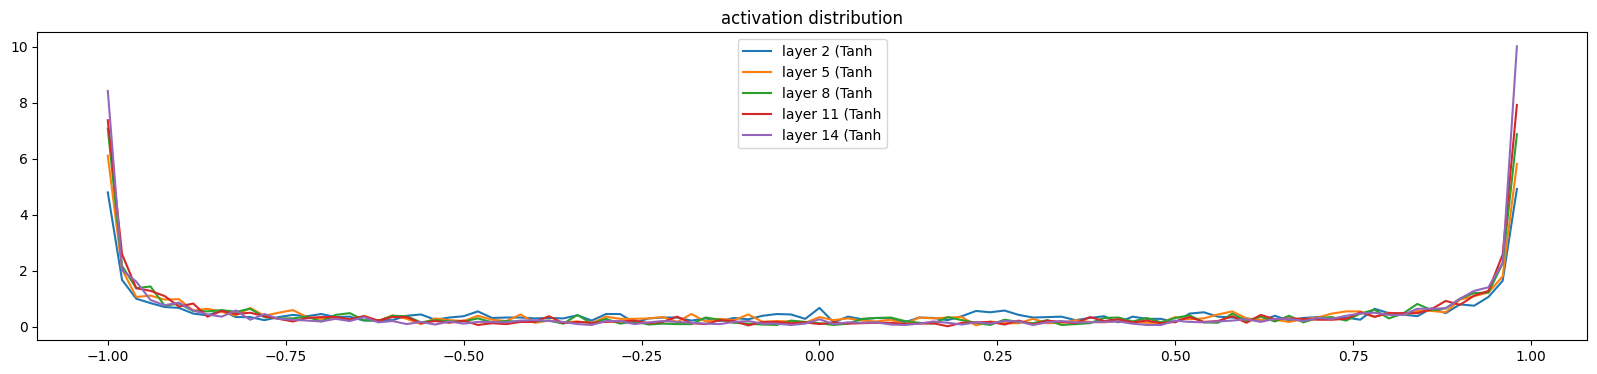

In [8]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 3.068986e-03
layer 5 (      Tanh): mean +0.000000, std 2.910315e-03
layer 8 (      Tanh): mean -0.000000, std 2.777515e-03
layer 11 (      Tanh): mean -0.000000, std 2.583117e-03
layer 14 (      Tanh): mean +0.000000, std 3.119943e-03


Text(0.5, 1.0, 'gradient distribution')

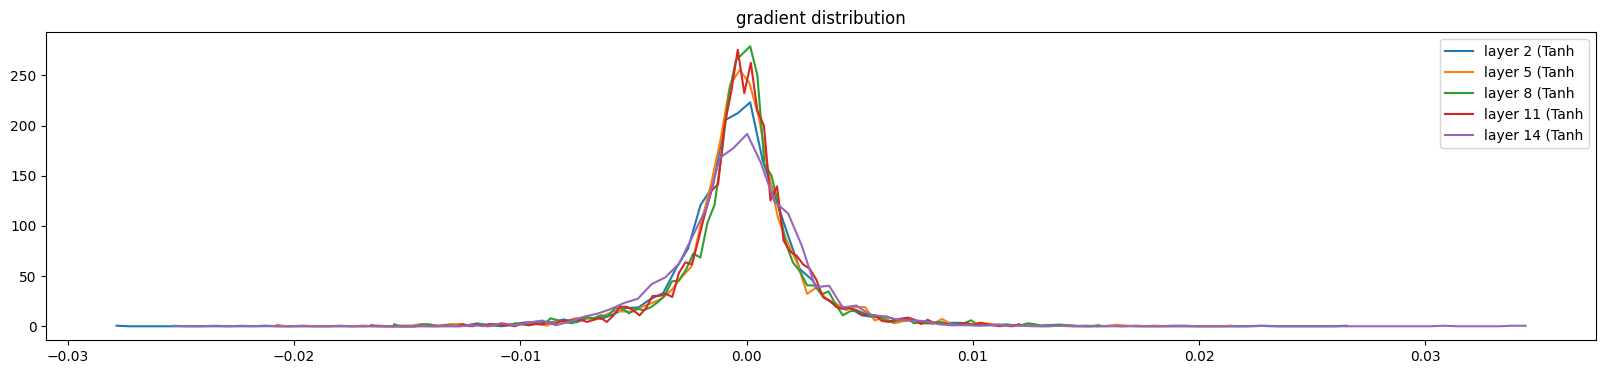

In [9]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 1.992750e-02 | grad:data ratio 1.666985e-02
weight  (30, 100) | mean -0.000070 | std 6.210309e-03 | grad:data ratio 1.126796e-02
weight (100, 100) | mean -0.000002 | std 2.483798e-03 | grad:data ratio 5.194088e-03
weight (100, 100) | mean -0.000047 | std 2.388545e-03 | grad:data ratio 4.997711e-03
weight (100, 100) | mean -0.000017 | std 2.216940e-03 | grad:data ratio 4.628188e-03
weight (100, 100) | mean -0.000010 | std 1.817143e-03 | grad:data ratio 3.744324e-03
weight  (100, 27) | mean -0.000100 | std 5.746826e-03 | grad:data ratio 1.117412e-02


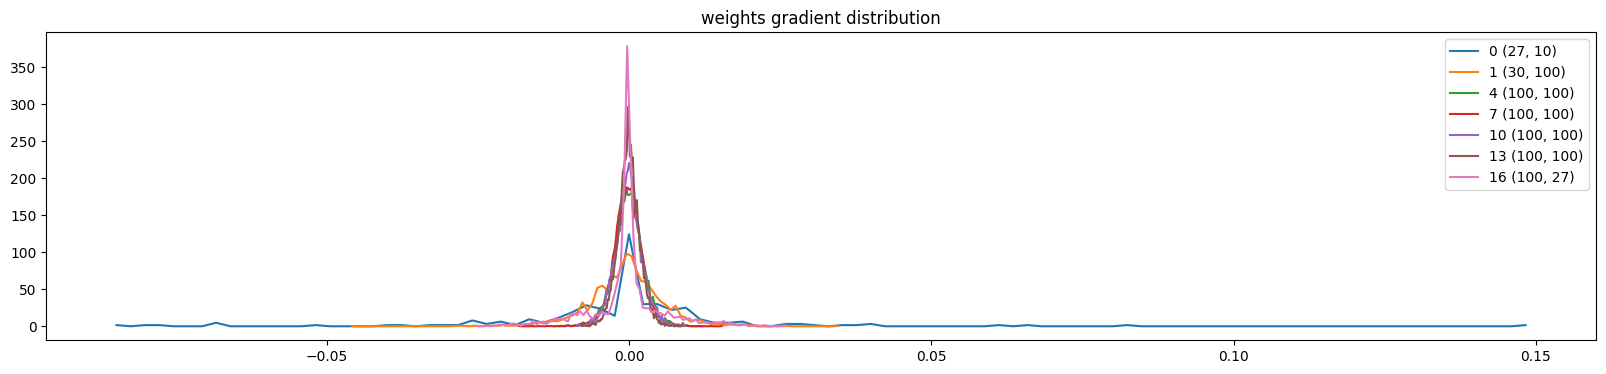

In [10]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

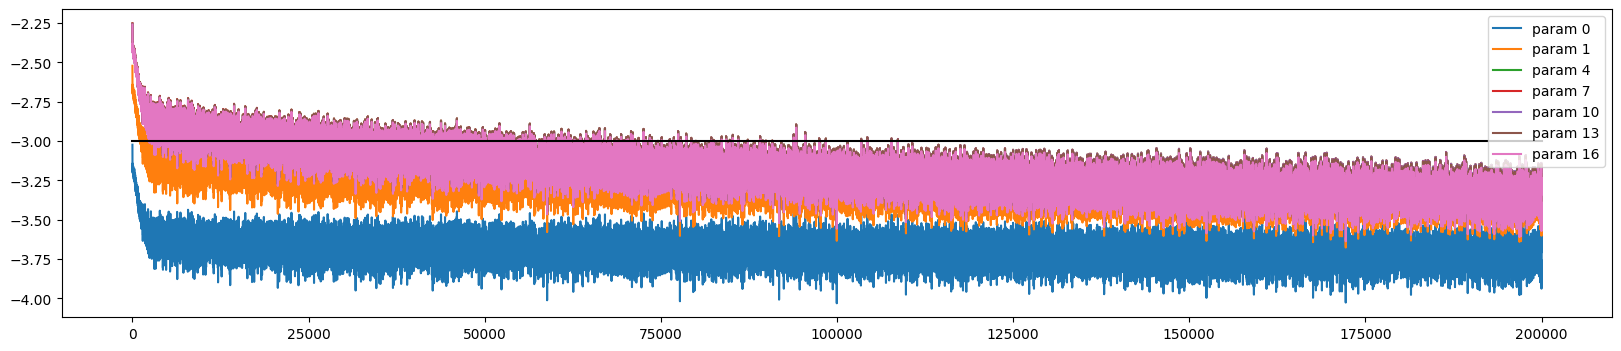

In [11]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [12]:
#defining func to calc loss on the splitted datasets
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdv, Ydv),
        'test': (Xts, Yts)
    } [split]
    emb = C[x]
    x = emb.view(emb.shape[0],-1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x,y)
    print(split, loss.item())

#turning of training mode for layers and evaluating the loss on train and val sets
for layer in layers:
    layer.training = False
split_loss('train')
split_loss('val')

train 2.0221376419067383
val 2.100627899169922


In [13]:
# Metrics using step learning rate decay
# train 2.003866195678711
# val 2.0925161838531494

# Metrics using adam optimisation
# train 2.0221376419067383
# val 2.100627899169922

In [14]:
#sampling from our model:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carmahzadelle.
khyrilyn.
taty.
skaan.
kena.
huba.
deliah.
jareei.
nellara.
chaiiv.
kaleigh.
ham.
joce.
quintis.
lilea.
jamilio.
jero.
dearyxi.
jace.
pinsley.


In [46]:
# Sampled Outputs with step learning rate decay:
# carmah.
# amorie.
# khyrmeli.
# tatyannah.
# skyla.
# hutcalee.
# rhylereni.
# nellara.
# chriha.
# kaleigh.
# ham.
# joce.
# quinthonova.
# alianni.
# wavero.
# dearyxi.
# jaxen.
# dura.
# med.
# edi.

# Samples Outputs with adam optimisation
# carmahzadelle.
# khyrilyn.
# taty.
# skaan.
# kena.
# huba.
# deliah.
# jareei.
# nellara.
# chaiiv.
# kaleigh.
# ham.
# joce.
# quintis.
# lilea.
# jamilio.
# jero.
# dearyxi.
# jace.
# pinsley.